# PyTorch 第三章：数据模块

> 核心目标：理解一条数据怎样从 **原始数据 → Dataset → transforms → DataLoader → batch → model**。

本 Notebook 结合《PyTorch 实用教程（第二版）》第三章整理，并按当前 PyTorch / TorchVision 常用实践做适度更新。

学习顺序：

1. **3.1 Dataset**：定义“一个样本怎么读”
2. **3.2 DataLoader**：定义“样本怎么组成 batch”
3. **3.3 常用 API 与 Sampler**：划分、拼接、采样
4. **3.4 transforms**：数据预处理与在线增强
5. **3.5 torchvision Dataset**：学习标准数据集的组织方式

参考：
- https://tingsongyu.github.io/PyTorch-Tutorial-2nd/chapter-3/
- https://docs.pytorch.org/docs/stable/data.html
- https://docs.pytorch.org/vision/stable/


In [1]:
import torch
import torchvision

from torch.utils.data import (
    Dataset, DataLoader, TensorDataset,
    ConcatDataset, Subset, random_split,
    WeightedRandomSampler
)

torch.manual_seed(42)

print("PyTorch:", torch.__version__)
print("TorchVision:", torchvision.__version__)

PyTorch: 2.11.0+cu128
TorchVision: 0.26.0+cu128


## 3.1 Dataset：定义一个样本怎么读取

对于最常见的 **map-style Dataset**，核心是：

```python
__len__()      # 数据集有多少个样本
__getitem__()  # 给一个 index，返回一个样本
```

关系：

`原始数据 → Dataset[index] → (data, label)`

Dataset 负责**读取和处理单个样本**，DataLoader 再负责组成 batch。


In [2]:
# 最小自定义 Dataset
class MyDataset(Dataset):
    def __init__(self):
        self.x = torch.arange(20, dtype=torch.float32).reshape(10, 2)
        self.y = torch.arange(10) % 2

    def __len__(self):
        return len(self.y)

    def __getitem__(self, index):
        # 返回一个样本：特征 + 标签
        return self.x[index], self.y[index]

dataset = MyDataset()

print("数据量:", len(dataset))
print("第 0 个样本:", dataset[0])
print("第 3 个样本:", dataset[3])

数据量: 10
第 0 个样本: (tensor([0., 1.]), tensor(0))
第 3 个样本: (tensor([6., 7.]), tensor(1))


### 自定义 Dataset 的通用模板

实际项目中，`__init__()` 通常先保存图片路径、标签或 CSV/JSON 元信息；`__getitem__(index)` 再完成：

1. 根据 index 找到样本
2. 读取数据
3. 做 transform
4. 返回 `(data, label)`

> 大数据集通常不要在 `__init__()` 中一次性把全部图片读进内存。


## 3.2 DataLoader：把样本组成 batch

最常用参数：

- `batch_size`：每批多少样本
- `shuffle=True`：训练集通常每个 epoch 打乱
- `num_workers`：并行读取数据的 worker 数
- `drop_last=True`：丢掉最后不足一个完整 batch 的数据

可以粗略理解为：

`Sampler 选 index → Dataset[index] 取样本 → collate_fn 组成 batch`


In [3]:
loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

for batch_idx, (x, y) in enumerate(loader):
    print(f"batch {batch_idx}")
    print("x.shape:", x.shape)
    print("y:", y)

batch 0
x.shape: torch.Size([4, 2])
y: tensor([0, 0, 1, 1])
batch 1
x.shape: torch.Size([4, 2])
y: tensor([0, 1, 0, 1])
batch 2
x.shape: torch.Size([2, 2])
y: tensor([0, 1])


### `num_workers` 怎么选？

学习和调试阶段推荐先用：

```python
num_workers=0
```

原因是报错位置清楚、Notebook 更稳定。正式训练时如果数据加载成为瓶颈，再逐步增大并做 benchmark。

GPU 训练还常见 `pin_memory=True`，它可能改善 CPU→GPU 数据拷贝，但不是必然更快。


In [4]:
# drop_last 的效果
small_dataset = TensorDataset(torch.arange(10))

keep_last = DataLoader(small_dataset, batch_size=4, drop_last=False)
drop_last = DataLoader(small_dataset, batch_size=4, drop_last=True)

print("drop_last=False:", [batch[0].tolist() for batch in keep_last])
print("drop_last=True :", [batch[0].tolist() for batch in drop_last])

drop_last=False: [[0, 1, 2, 3], [4, 5, 6, 7], [8, 9]]
drop_last=True : [[0, 1, 2, 3], [4, 5, 6, 7]]


## 3.3 Dataset 常用 API

入门阶段重点掌握：

- `ConcatDataset`：拼接多个 Dataset
- `Subset`：按索引取子集
- `random_split`：随机划分数据集
- `WeightedRandomSampler`：按权重采样

其中最常见的是训练集 / 验证集划分。


先学最实用的一个：`TensorDataset`。

如果你的数据已经是 Tensor：

```
x = torch.randn(6, 3)
y = torch.tensor([0, 1, 0, 1, 0, 1])
```

没必要再专门写一个自定义 `Dataset`，可以直接：

```
from torch.utils.data import TensorDataset

dataset = TensorDataset(x, y)
```

然后：

```
dataset[0]
```

会返回：

```
(x[0], y[0])
```

所以可以把 `TensorDataset` 理解成：

> **把多个第一维长度相同的 Tensor 按样本维绑定在一起。

random_split：随机划分数据集。**不会复制原始数据**，而是保存属于自己那部分的索引。

In [ ]:
# random_split：固定随机种子，保证划分可复现
full_dataset = TensorDataset(
    torch.arange(20).reshape(10, 2),
    torch.arange(10)
)
# 固定随机种子，保证每次划分结果一模一样
generator = torch.Generator().manual_seed(42)

train_set, val_set = random_split(
    full_dataset,
    [8, 2],
    generator=generator
)

print("train:", len(train_set))
print("val  :", len(val_set))
print("val indices:", val_set.indices)

train: 8
val  : 2
val indices: [3, 7]


Subset
不是复制数据
而是保存“我要哪些 index”

In [6]:
# ConcatDataset + Subset
d1 = TensorDataset(torch.tensor([[1.], [2.]]), torch.tensor([0, 0]))
d2 = TensorDataset(torch.tensor([[3.], [4.]]), torch.tensor([1, 1]))

merged = ConcatDataset([d1, d2])
part = Subset(merged, indices=[0, 2, 3])

print("merged length:", len(merged))
print("subset:")
for sample in part:
    print(sample)

merged length: 4
subset:
(tensor([1.]), tensor(0))
(tensor([3.]), tensor(1))
(tensor([4.]), tensor(1))


**`ConcatDataset`**
核心理解：

> `ConcatDataset` 是把多个 Dataset **首尾拼接成一个大的 Dataset**。

它不是 Tensor 的 `torch.cat()`。`torch.cat()` 拼的是 Tensor；`ConcatDataset` 拼的是 Dataset 对象。

In [14]:
from torch.utils.data import TensorDataset, ConcatDataset

d1 = TensorDataset(
    torch.tensor([[1.], [2.]]),
    torch.tensor([0, 0])
)

d2 = TensorDataset(
    torch.tensor([[3.], [4.]]),
    torch.tensor([1, 1])
)

merged = ConcatDataset([d1, d2])
len(merged)

4

### Sampler 控制什么？

Sampler 决定：

> **DataLoader 下一步去 Dataset 取哪个 index。**

常见情况：

```text
shuffle=False → 顺序采样
shuffle=True  → 随机采样
```

类别严重不均衡时，可以使用 `WeightedRandomSampler` 提高少数类被抽到的概率。


In [7]:
# WeightedRandomSampler：让少数类更容易被采到
# 原始标签：0 有 8 个，1 只有 2 个
labels = torch.tensor([0,0,0,0,0,0,0,0,1,1])
features = torch.arange(10).float().unsqueeze(1)

imbalanced_dataset = TensorDataset(features, labels)

class_count = torch.bincount(labels)
print("原始类别数量:", class_count.tolist())

# 每类使用样本数量倒数作为权重
class_weight = 1.0 / class_count.float()

# 注意：Sampler 最终接收的是“每个样本”的权重
sample_weight = class_weight[labels]

sampler = WeightedRandomSampler(
    weights=sample_weight,
    num_samples=len(labels),
    replacement=True
)

balanced_loader = DataLoader(
    imbalanced_dataset,
    batch_size=10,
    sampler=sampler
)

_, sampled_labels = next(iter(balanced_loader))

print("一次加权采样结果:", sampled_labels.tolist())
print("采样后类别数量:", torch.bincount(sampled_labels, minlength=2).tolist())

原始类别数量: [8, 2]
一次加权采样结果: [0, 1, 1, 0, 0, 0, 0, 1, 1, 0]
采样后类别数量: [6, 4]


注意：

- `WeightedRandomSampler` 是概率采样，不保证每个 batch 严格 1:1。
- `sampler=...` 与 `shuffle=True` 通常不要同时设置，因为采样顺序已经由 sampler 决定。


## 3.4 transforms：预处理与在线数据增强

教程中的核心思想仍然有效：

> transform 通常在 `Dataset.__getitem__()` 中执行，因此每次样本被读取时都可以做在线变换。

典型流程：

`读取图片 → Resize → 随机增强 → 转 Tensor → Normalize`

### 数据增强原则

增强不是越多越好，而应模拟真实测试数据可能出现的变化。

当前 TorchVision 更推荐 `torchvision.transforms.v2`，下面使用 v2。


In [ ]:
from PIL import Image
import numpy as np
from torchvision.transforms import v2

# 生成一张模拟 RGB 图片，不依赖外部下载
img_array = np.random.default_rng(42).integers(
    0, 256, size=(40, 60, 3), dtype=np.uint8
)
img = Image.fromarray(img_array)

transform = v2.Compose([
    # 将输入(PIL图/numpy数组)统一转为torch图像张量，格式C,H,W，dtype=uint8
    v2.ToImage(),
    # 将图像resize到固定尺寸 高32，宽32
    v2.Resize((32, 32)),
    # 随机水平翻转，每张图片有50%概率左右镜像，数据增强（训练集用）
    v2.RandomHorizontalFlip(p=0.5),
    # 把uint8[0,255]转float32；scale=True自动把像素缩放到[0,1]区间
    v2.ToDtype(torch.float32, scale=True),
    # 标准化：(x - mean) / std
    v2.Normalize(
        mean=[0.5, 0.5, 0.5],   # RGB三通道均值
        std=[0.5, 0.5, 0.5]     # RGB三通道标准差
    )
])

x = transform(img)

print("原始图片 size:", img.size)   # PIL: (W, H)
print("处理后 shape :", x.shape)    # Tensor: (C, H, W)
print("dtype:", x.dtype)
print("范围:", float(x.min()), float(x.max()))

原始图片 size: (60, 40)
处理后 shape : torch.Size([3, 32, 32])
dtype: torch.float32
范围: -0.7333333492279053 0.7490197420120239


**transform 应该放在哪里**。

典型 Dataset：

```
class MyDataset(Dataset):
    def __init__(self, transform=None):
        self.transform = transform

    def __getitem__(self, index):
        image = read_image(...)

        if self.transform is not None:
            image = self.transform(image)

        return image
```

因此流程是：

```
DataLoader 请求 index
        ↓
Dataset.__getitem__()
        ↓
读取原始样本
        ↓
transform
        ↓
返回处理后的样本
```

这意味着随机 transform 通常是**每次取样时执行**的，而不是提前把增强后的图片永久保存下来。

### `Compose` 怎么工作？

```python
v2.Compose([A, B, C])
```

等价于：

`输入 → A → B → C → 输出`

因此前一个 transform 的输出必须能被后一个 transform 接收。

高频操作：

- `Resize`：改变尺寸
- `RandomHorizontalFlip`：随机水平翻转
- `ToDtype(..., scale=True)`：转浮点并缩放
- `Normalize`：逐通道标准化

Normalize：

$y=(x-mean)/std$


In [9]:
# Normalize 的最小验证
x = torch.tensor([[[0.0, 0.5, 1.0]]])  # [C,H,W]

normalize = v2.Normalize(mean=[0.5], std=[0.5])
y = normalize(x)

print("before:", x)
print("after :", y)

# 0   -> -1
# 0.5 ->  0
# 1   ->  1

before: tensor([[[0.0000, 0.5000, 1.0000]]])
after : tensor([[[-1.,  0.,  1.]]])


## 3.5 torchvision Dataset：学习标准实现

TorchVision 已提供大量标准 Dataset，例如 MNIST、CIFAR10、COCO、VOC、`ImageFolder`。

这里真正要学的是**设计模式**。

自己的图像分类项目如果按下面方式组织：

```text
root/
├── cat/
│   ├── 001.jpg
│   └── 002.jpg
└── dog/
    ├── 001.jpg
    └── 002.jpg
```

可以直接使用 `ImageFolder`，文件夹名自动成为类别名。


In [ ]:
# 构造一个最小 ImageFolder 数据集，避免网络下载
from pathlib import Path
from tempfile import TemporaryDirectory
from torchvision.datasets import ImageFolder

# 创建临时目录，程序结束自动删除
_tmp = TemporaryDirectory()
root = Path(_tmp.name)

# 构建两个类别文件夹：class_a、class_b，base_value用来区分图片像素底色
for cls_name, base_value in [("class_a", 50), ("class_b", 200)]:
    # 拼接类别文件夹路径
    cls_dir = root / cls_name
    # 创建文件夹，parents=True自动创建上级目录
    cls_dir.mkdir(parents=True)
    # 每个类别生成3张16×16的彩色png图片
    for i in range(3):
        # 生成np数组：shape(H,W,3)，像素值=base_value+i，uint8图片格式
        arr = np.full((16, 16, 3), base_value + i, dtype=np.uint8)
        # numpy数组转PIL图像，保存到对应类别文件夹
        Image.fromarray(arr).save(cls_dir / f"{i}.png")
######################################################

image_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

image_dataset = ImageFolder(
    root=root,
    transform=image_transform
)

print("classes:", image_dataset.classes)
print("class_to_idx:", image_dataset.class_to_idx)
print("样本数:", len(image_dataset))

sample_x, sample_y = image_dataset[0]
print("sample shape:", sample_x.shape)
print("sample label:", sample_y)

classes: ['class_a', 'class_b']
class_to_idx: {'class_a': 0, 'class_b': 1}
样本数: 6
sample shape: torch.Size([3, 16, 16])
sample label: 0


In [11]:
# ImageFolder + DataLoader：单个样本最终组成 batch
image_loader = DataLoader(
    image_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0
)

images, labels = next(iter(image_loader))

print("images.shape:", images.shape)  # [B,C,H,W]
print("labels.shape:", labels.shape)
print("labels:", labels)

images.shape: torch.Size([2, 3, 16, 16])
labels.shape: torch.Size([2])
labels: tensor([0, 0])


接下来学 **torchvision 内置标准数据集**。

例如 MNIST：
root      → 数据保存位置
train     → True 表示训练集，False 表示测试集
download  → 本地没有时是否自动下载
transform → 每个样本读取后做的预处理

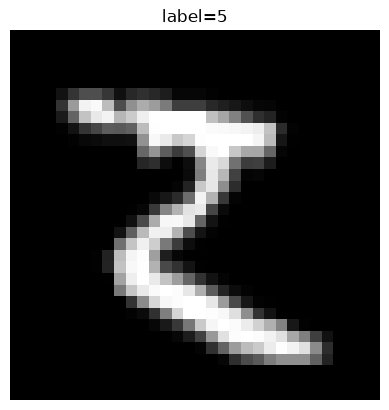

In [32]:
from torchvision.datasets import MNIST

transform = v2.Compose([
    v2.ToImage(),
    v2.Resize((32, 32)),
    v2.RandomHorizontalFlip(p=0.5),
    v2.ToDtype(torch.float32, scale=True),
    # 单通道mean/std！！
    v2.Normalize(mean=[0.5], std=[0.5])
])

train_set = MNIST(
    root="/mnt/study/github/PyTorch-Tutorial-2nd/data",
    train=True,
    download=True,
    transform=transform
)
image, label = train_set[0]

import matplotlib.pyplot as plt
def plot(img_tensor, label):
    # 反归一化
    img = img_tensor * 0.5 + 0.5
    #  squeeze去掉通道维度 (1,32,32) → (32,32)
    img = img.squeeze().cpu().numpy()
    plt.imshow(img, cmap="gray")
    plt.title(f"label={label}")
    plt.axis("off")
    plt.show()

image, label = train_set[0]
plot(image, label)

# 第三章总结

这一章不需要背大量 API，只要把下面这条链彻底搞清楚：

```text
原始数据
   ↓
Dataset.__getitem__(index)
   ↓
读取一个样本
   ↓
transform
   ↓
(data, label)
   ↓
Sampler 选择 index
   ↓
DataLoader
   ↓
collate_fn
   ↓
Batch
   ↓
model(batch)
```

必须会回答：

1. `Dataset` 和 `DataLoader` 分别负责什么？
2. 为什么自定义 Dataset 通常需要 `__len__()` 和 `__getitem__()`？
3. `batch_size / shuffle / num_workers / drop_last` 分别有什么作用？
4. Sampler 控制什么？
5. `random_split` 为什么最好固定 `Generator`？
6. `WeightedRandomSampler` 的权重最终是给类别还是每个样本？
7. transform 为什么通常在 `__getitem__()` 中执行？
8. `Compose` 如何工作？
9. PIL / NumPy 图片变成 Tensor 后，常见维度为什么是 `C×H×W`？
10. `ImageFolder` 的目录结构是什么？

> **Dataset 决定一个样本怎么来，DataLoader 决定这些样本怎么被取出并组成 batch。**
